# Road Accident Analysis and Prediction in India

This project focuses on analyzing road accident data using Exploratory Data Analysis (EDA), 
data cleaning, and machine learning techniques.

Objectives:
- Analyze year-wise and state-wise trends
- Identify major accident causes and influencing factors
- Study accident severity patterns
- Build classification and regression models
- Develop a risk-based analytical approach

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('final.csv')
df


,SNo,Year,State_UT,City,Road_Classification,Mode_of_Transport,Total_Accidents,Persons_Injured,Persons_Killed,Accident_Cause,Time_of_Accident,Road_Condition,Light_Condition,Weather_Condition,Injury_Severity,Junction_Type,Source
0,1,2019,Chandigarh,Chandigarh,City Roads,Others,1371,1580,473,Bad Road Condition,09:00-12:00,Under Repair,Dark - Street Light On,Cloudy,No Injury,T-Junction,data.gov.in - Ministry of Road Transport & Hig...
1,2,2021,Telangana,Karimnagar,Other Roads,Others,8109,13206,1433,Poor Weather Visibility,18:00-21:00,Wet,Dark - No Street Light,Foggy,Minor Injury,No Junction,data.gov.in - Ministry of Road Transport & Hig...
2,3,2022,Nagaland,Nagaland,City Roads,Car/Jeep/Taxi,7495,15437,1373,Vehicle Defect,21:00-24:00,Flooded,Dark - No Street Light,Rainy,No Injury,T-Junction,data.gov.in - Ministry of Road Transport & Hig...
3,4,2019,Uttar Pradesh,Varanasi,City Roads,Others,146,240,37,Tyre Burst,18:00-21:00,Wet,Dark - Street Light On,Misty,Grievous Injury,Four-Arm Junction,data.gov.in - Ministry of Road Transport & Hig...
4,5,2020,Lakshadweep,Lakshadweep,National Highway,Others,4996,7006,317,Wrong Side Driving,15:00-18:00,Under Repair,Dark - No Street Light,Rainy,Minor Injury,Y-Junction,data.gov.in - Ministry of Road Transport & Hig...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,2021,Maharashtra,Nashik,Other Roads,Car/Jeep/Taxi,7224,12701,1221,Jumping Red Light,09:00-12:00,Dry,Dark - No Street Light,Foggy,Grievous Injury,T-Junction,data.gov.in - Ministry of Road Transport & Hig...
1496,1497,2022,Kerala,Thrissur,Expressway,Bus,11071,10455,3229,Over Speeding,15:00-18:00,Dry,Dusk/Dawn,Rainy,Grievous Injury,Roundabout,data.gov.in - Ministry of Road Transport & Hig...
1497,1498,2021,Tripura,Tripura,Expressway,Others,5451,7820,1241,Wrong Side Driving,15:00-18:00,Wet,Dusk/Dawn,Rainy,Fatal,T-Junction,data.gov.in - Ministry of Road Transport & Hig...
1498,1499,2022,Punjab,Jalandhar,Expressway,Others,8540,10603,1349,Tyre Burst,15:00-18:00,Potholed,Dusk/Dawn,Misty,Minor Injury,No Junction,data.gov.in - Ministry of Road Transport & Hig...


## Dataset Overview

This section provides a basic understanding of the dataset including structure, 
data types, and summary statistics.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   SNo                  1500 non-null   int64
 1   Year                 1500 non-null   int64
 2   State_UT             1500 non-null   str  
 3   City                 1500 non-null   str  
 4   Road_Classification  1500 non-null   str  
 5   Mode_of_Transport    1500 non-null   str  
 6   Total_Accidents      1500 non-null   int64
 7   Persons_Injured      1500 non-null   int64
 8   Persons_Killed       1500 non-null   int64
 9   Accident_Cause       1500 non-null   str  
 10  Time_of_Accident     1500 non-null   str  
 11  Road_Condition       1500 non-null   str  
 12  Light_Condition      1500 non-null   str  
 13  Weather_Condition    1500 non-null   str  
 14  Injury_Severity      1500 non-null   str  
 15  Junction_Type        1500 non-null   str  
 16  Source               1500 non-null 

,SNo,Year,Total_Accidents,Persons_Injured,Persons_Killed
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,2020.980667,5961.693333,9875.275333,1194.210667
std,433.157015,1.403902,3502.172853,6789.962881,933.659171
min,1.000000,2019.000000,10.000000,10.000000,2.000000
25%,375.750000,2020.000000,2965.250000,4386.250000,425.000000
50%,750.500000,2021.000000,5957.500000,8727.000000,964.000000
75%,1125.250000,2022.000000,9013.250000,14423.750000,1758.250000
max,1500.000000,2023.000000,11997.000000,28736.000000,4085.000000


## Data Cleaning

The dataset is cleaned by removing duplicates, handling missing values, 
and standardizing column formats.

In [4]:
df.drop_duplicates(inplace=True)

df.fillna('Unknown', inplace=True)

df.columns = df.columns.str.strip()

df['Year'] = df['Year'].astype(int)

# Insight:
# Ensures consistency and prevents errors in analysis

## Feature Engineering

New variables are created to enhance analysis:
- Fatal: Binary classification target
- Fatality Rate: Severity indicator

In [5]:
df['Fatal'] = df['Persons_Killed'].apply(lambda x: 1 if x > 0 else 0)

df['Fatality_Rate'] = df['Persons_Killed'] / df['Total_Accidents']

# Insight:
# These features help in classification and severity analysis

## Year-wise Trend Analysis

This visualization shows how accidents, injuries, and fatalities change over time.

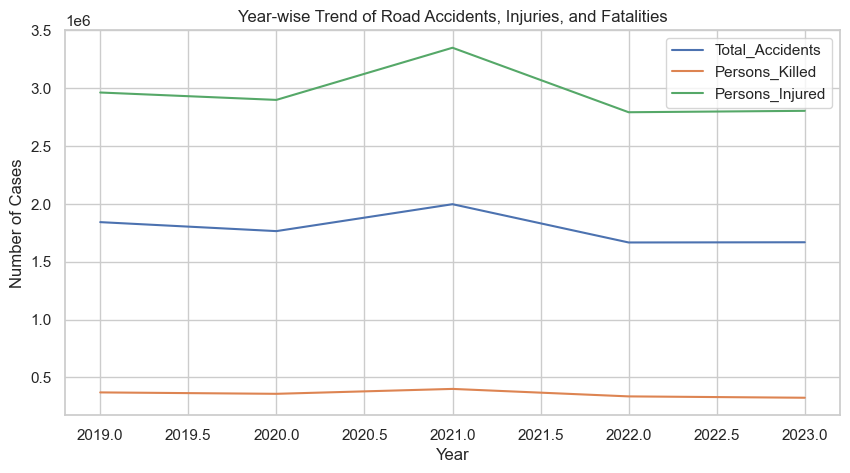

In [6]:
yearly = df.groupby('Year')[['Total_Accidents','Persons_Killed','Persons_Injured']].sum()

yearly.plot(figsize=(10,5))
plt.title("Year-wise Trend of Road Accidents, Injuries, and Fatalities")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()

# Insight:
# Reveals whether road safety conditions are improving or deteriorating

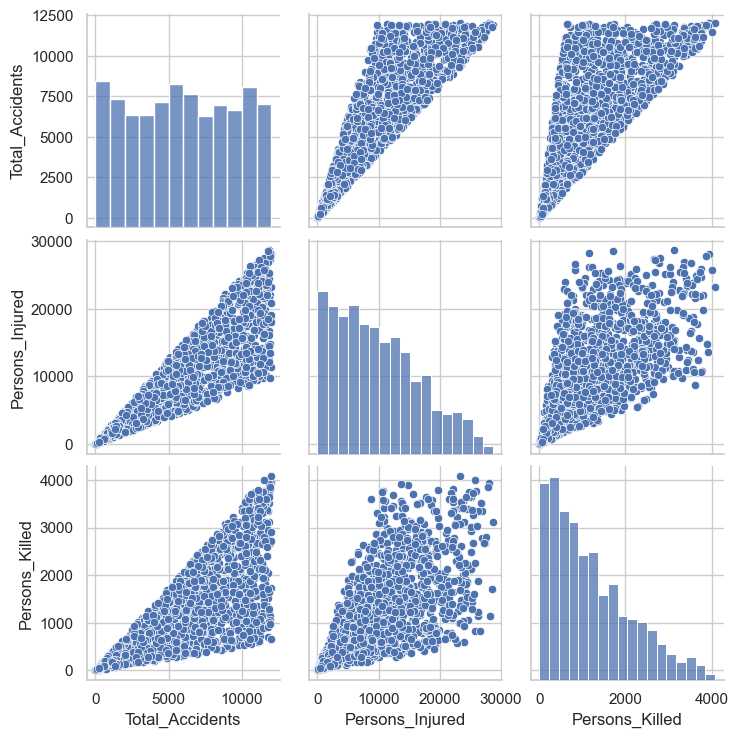

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important columns
cols = ['Total_Accidents', 'Persons_Injured', 'Persons_Killed']

# Create pair plot
sns.pairplot(df[cols])

plt.show()

## State-wise Analysis

Identifies states with the highest number of accidents.

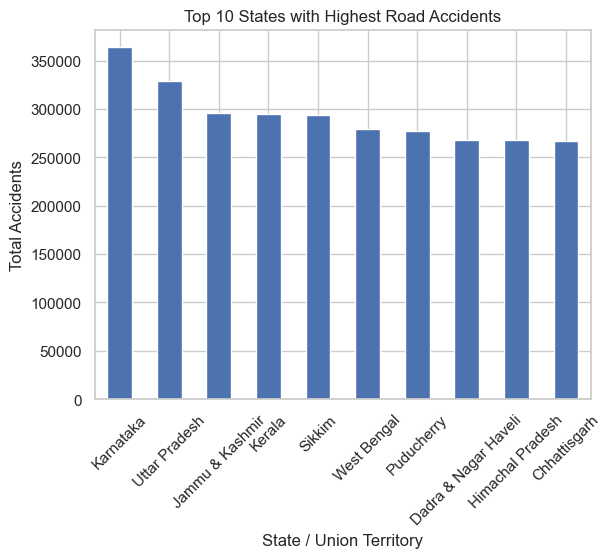

In [7]:
top_states = df.groupby('State_UT')['Total_Accidents'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title("Top 10 States with Highest Road Accidents")
plt.xlabel("State / Union Territory")
plt.ylabel("Total Accidents")
plt.xticks(rotation=45)
plt.show()

# Insight:
# Highlights high-risk regions for targeted safety measures

## Accident Causes Analysis

Examines the primary causes contributing to accidents.

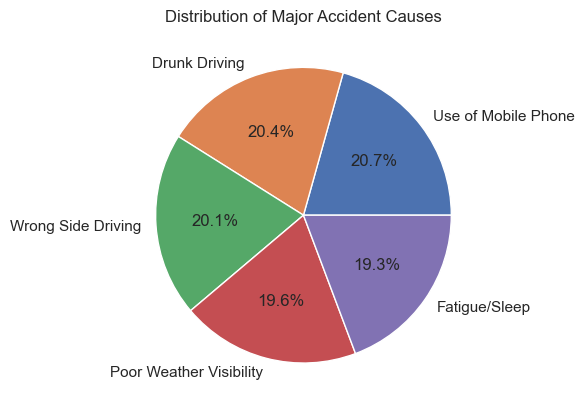

In [8]:
causes = df['Accident_Cause'].value_counts().head(5)

plt.pie(causes, labels=causes.index, autopct='%1.1f%%')
plt.title("Distribution of Major Accident Causes")
plt.show()

# Insight:
# Helps identify dominant causes such as overspeeding or negligence

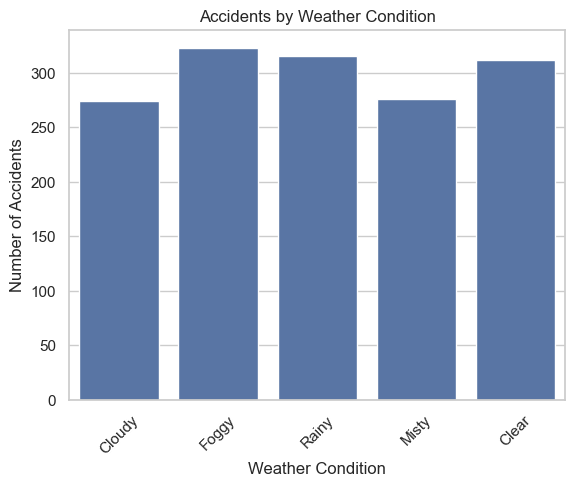

In [9]:
sns.countplot(data=df, x='Weather_Condition')
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

# Insight:
# Adverse weather increases accident risk, but human factors remain dominant

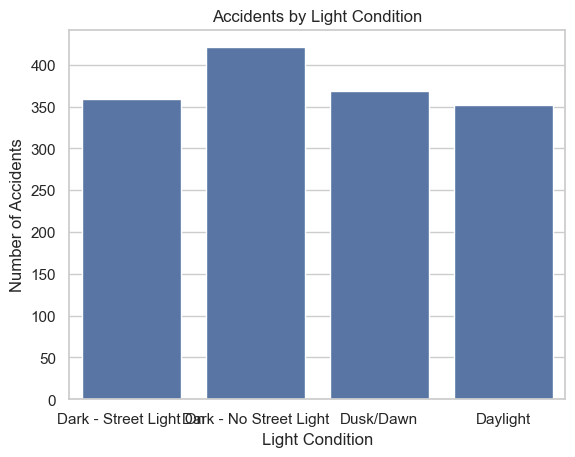

In [10]:
sns.countplot(data=df, x='Light_Condition')
plt.title("Accidents by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("Number of Accidents")
plt.show()

# Insight:
# Night conditions often lead to more severe accidents

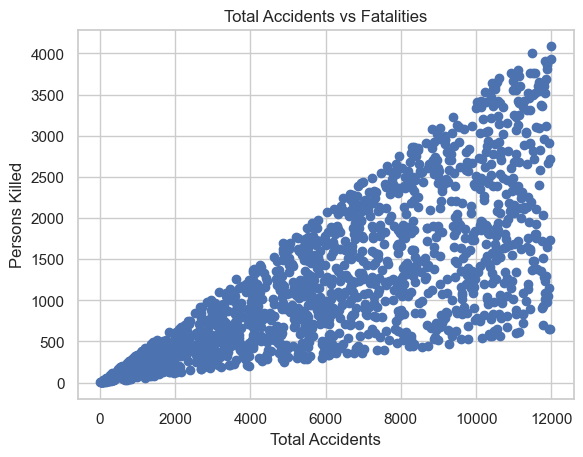

In [12]:
plt.scatter(df['Total_Accidents'], df['Persons_Killed'])
plt.title("Total Accidents vs Fatalities")
plt.xlabel("Total Accidents")
plt.ylabel("Persons Killed")
plt.show()

# Insight:
# Shows positive relationship between accidents and deaths

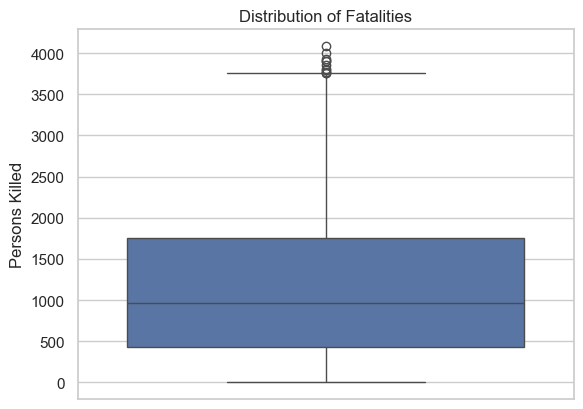

In [13]:
sns.boxplot(data=df, y='Persons_Killed')
plt.title("Distribution of Fatalities")
plt.ylabel("Persons Killed")
plt.show()

# Insight:
# Detects extreme accident cases (outliers)

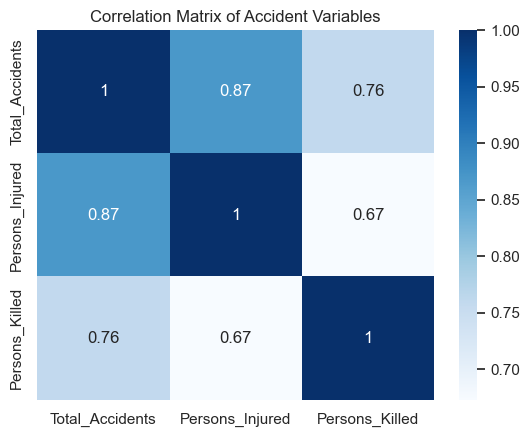

In [24]:
sns.heatmap(df[['Total_Accidents','Persons_Injured','Persons_Killed']].corr(), annot=True,cmap='Blues')
plt.title("Correlation Matrix of Accident Variables")
plt.show()

# Insight:
# Strong correlation confirms relationship between accidents and casualties

## Regression Model

Predicts number of fatalities based on accident data.

In [18]:
#from the above heatmap we can cunclude that independent variable is total_accidents and dependent variable is persons_injured
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features (input)
X = df[['Total_Accidents']]

# Target (output)
y = df['Persons_Injured']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# R² Score
r2 = r2_score(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Print results
print("R² Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

R² Score: 0.748348870280519
MSE: 11985980.019108318
MAE: 2607.268136387253


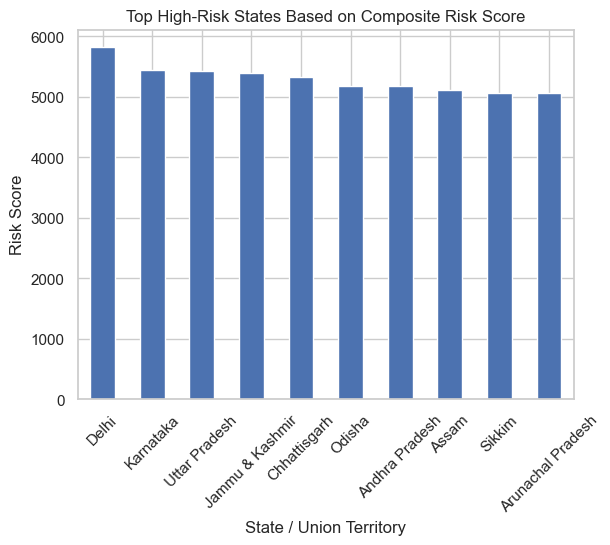

In [22]:
df['Risk_Score'] = (
    df['Persons_Killed'] * 0.5 +
    df['Persons_Injured'] * 0.3 +
    df['Total_Accidents'] * 0.2
)

top_risk = df.groupby('State_UT')['Risk_Score'].mean().sort_values(ascending=False).head(10)

top_risk.plot(kind='bar')
plt.title("Top High-Risk States Based on Composite Risk Score")
plt.xlabel("State / Union Territory")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

# Insight:
# Provides a more comprehensive measure of accident severity

## Conclusion

- Road accidents exhibit clear temporal and regional trends
- Certain states consistently show higher accident rates
- Human and environmental factors influence accident severity
- Machine learning models effectively predict accident outcomes
- Risk score enhances interpretation of accident severity

This analysis can support better road safety planning and policy decisions.